In [343]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression    
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score  
import matplotlib.pyplot as plt

In [344]:
df=pd.read_csv("Ice_cream selling data (1).csv")

In [345]:
df.head(10)

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [346]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [347]:
x=df.drop(columns='Ice Cream Sales (units)')
y=df['Ice Cream Sales (units)']

In [348]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

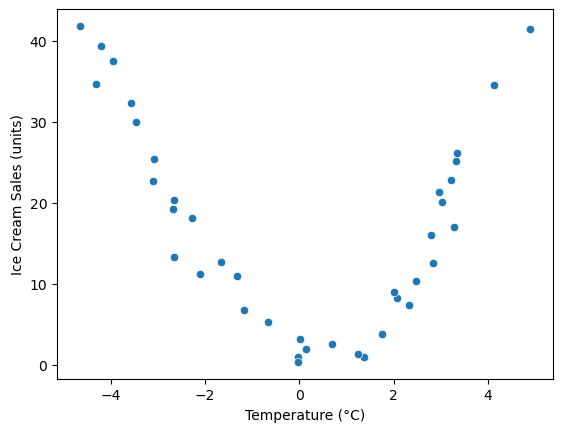

In [349]:
sns.scatterplot(x=xtrain['Temperature (°C)'],y=ytrain)

In [350]:
xtrain.head(10)

,Temperature (°C)
12,-2.111870
4,-3.578554
34,2.318591
8,-2.672461
3,-3.949661
6,-3.108440
40,3.211366
41,3.270044
46,4.130868
15,-1.326379


In [351]:
poly=PolynomialFeatures(degree=2)

In [352]:
updated_xtrain=poly.fit_transform(xtrain)

In [ ]:
updated_xtrain             # (x,x**2)  --> it gives features

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00],
       [ 1.00000000e+00,  6.88780908e-01,  4.74419139e-01],
       [ 1.00000000e+00,  2.07510060e+00,  4.30604249e+00],
       [ 1.00000000e+00,  1.74000001e+00,  3.02760004e+00],
       [ 1.00000000e+00, -4.66226268e+00,  2.17366933e+01],
       [ 1.00000000e+00,  3.33593241e+00

In [354]:
updated_xtest=poly.transform(xtest)

In [355]:
model=LinearRegression()

## Before applying polynomial features

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

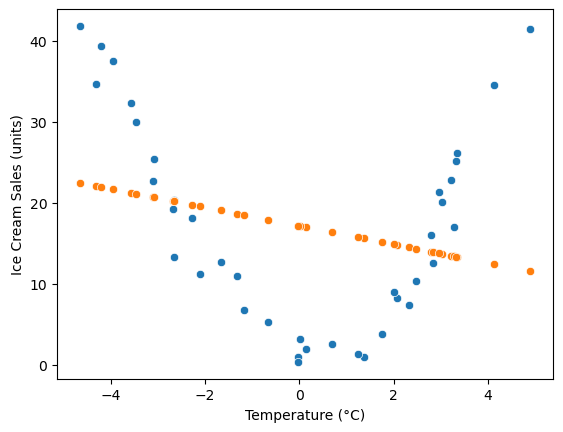

In [356]:
model.fit(xtrain,ytrain)                     
ytrain_pred=model.predict(xtrain)
sns.scatterplot(x=xtrain['Temperature (°C)'],y=ytrain)
sns.scatterplot(x=xtrain['Temperature (°C)'],y=ytrain_pred)

In [357]:
model.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [358]:
ytrain_pred_poly=model.predict(updated_xtrain)
ytest_pred_poly=model.predict(updated_xtest)

In [359]:
train_score=r2_score(ytrain,ytrain_pred_poly)
print(f"Test score: {train_score}")

Test score: 0.9413665676490518


In [360]:
test_score=r2_score(ytest,ytest_pred_poly)
print(f"Test score: {test_score}")

Test score: 0.8430551371938841


In [361]:
help(LinearRegression)

Help on class LinearRegression in module sklearn.linear_model._base:

class LinearRegression(sklearn.base.MultiOutputMixin, sklearn.base.RegressorMixin, LinearModel)
 |  LinearRegression(*, fit_intercept=True, copy_X=True, tol=1e-06, n_jobs=None, positive=False)
 |
 |  Ordinary least squares Linear Regression.
 |
 |  LinearRegression fits a linear model with coefficients w = (w1, ..., wp)
 |  to minimize the residual sum of squares between the observed targets in
 |  the dataset, and the targets predicted by the linear approximation.
 |
 |  Parameters
 |  ----------
 |  fit_intercept : bool, default=True
 |      Whether to calculate the intercept for this model. If set
 |      to False, no intercept will be used in calculations
 |      (i.e. data is expected to be centered).
 |
 |  copy_X : bool, default=True
 |      If True, X will be copied; else, it may be overwritten.
 |
 |  tol : float, default=1e-6
 |      The precision of the solution (`coef_`) is determined by `tol` which
 |   

## After applying polynomial features

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

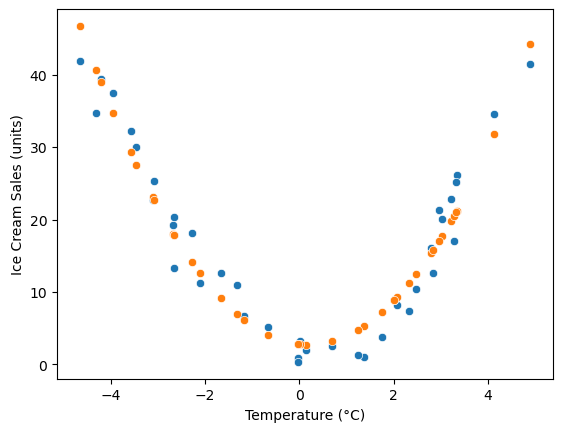

In [362]:
sns.scatterplot(x=xtrain['Temperature (°C)'],y=ytrain)
sns.scatterplot(x=xtrain['Temperature (°C)'],y=ytrain_pred_poly)

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

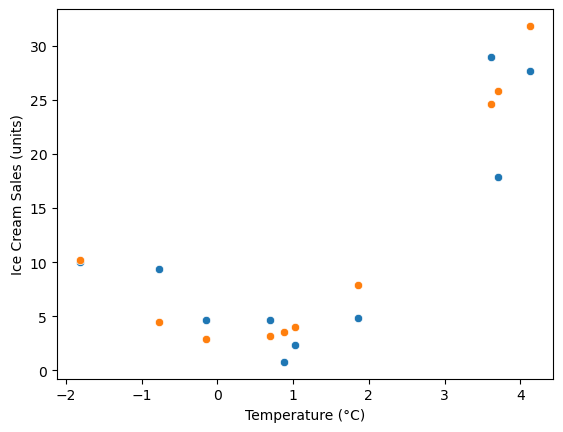

In [363]:
sns.scatterplot(x=xtest['Temperature (°C)'],y=ytest)
sns.scatterplot(x=xtest['Temperature (°C)'],y=ytest_pred_poly)

<Axes: ylabel='Ice Cream Sales (units)'>

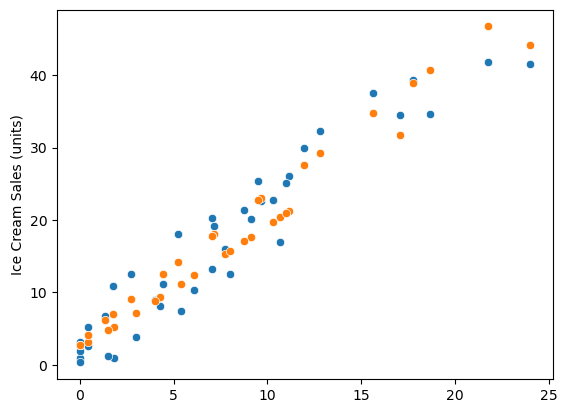

In [ ]:
sns.scatterplot(x=updated_xtrain[:,2],y=ytrain)        # Here, we have to check the by changing the number in updated_xtrain which fits the best.
sns.scatterplot(x=updated_xtrain[:,2],y=ytrain_pred_poly) 

<Axes: ylabel='Ice Cream Sales (units)'>

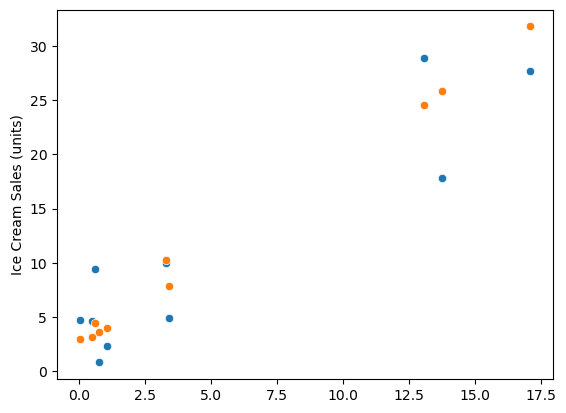

In [368]:
sns.scatterplot(x=updated_xtest[:,2],y=ytest)        
sns.scatterplot(x=updated_xtest[:,2],y=ytest_pred_poly) 